# Phase 4 — Market Calibration Analysis

---

## Objective

The objective is to evaluate whether prediction market probabilities are statistically calibrated.

A well-calibrated market should satisfy the following property:

 - Events assigned a probability of 70% should occur approximately 70% of the time.

 -  Events assigned a probability of 20% should occur approximately 20% of the time.

Calibration analysis is a fundamental step before attempting any Bayesian adjustment or mispricing detection framework.

If market probabilities are already perfectly calibrated, there may be little room for improvement.

Conversely, systematic calibration errors may indicate exploitable inefficiencies.

---

## Research Questions

This notebook investigates:

1. Are Polymarket probabilities calibrated?

2. Does the market systematically overestimate event probabilities?

3. Does the market systematically underestimate event probabilities?

4. Are extreme probabilities (near 0 or 1) justified by realized outcomes?

5. Is there evidence of systematic mispricing?

---

## Methodology

The analysis will focus on:

### 1. Probability Binning

Final market probabilities will be grouped into probability buckets.

Examples:

| Probability |
|------------|
| 0.10 |
| 0.20 |
| 0.35 |
| 0.80 |
| 0.95 |

These probabilities will be aggregated into bins and compared against realized outcomes.

---

### 2. Reliability Diagram

For each probability bucket:

Observed Frequency

vs

Predicted Probability

will be compared.

A perfectly calibrated market should lie close to the 45-degree line.

---

### 3. Brier Score

The Brier Score measures the accuracy of probabilistic forecasts.

Lower values indicate better calibration and forecasting performance.

The metric is defined as:

$ BS = \frac{1}{N} \sum_{i=1}^{N}(p_i - y_i)^2$

where:

- $ p_i $ = forecast probability
- $ y_i $  = realized outcome

---

### 4. Calibration Error

Calibration error measures the discrepancy between predicted probabilities and observed frequencies.
This provides a direct estimate of market miscalibration.

---

## Expected Outputs

At the end of this notebook we will obtain:

- Probability calibration table
- Reliability diagram
- Brier Score
- Calibration error statistics
- Evidence of overconfidence or underconfidence
- Initial assessment of market efficiency

---

## Connection to the Bayesian Framework

This phase is critical because it establishes the baseline market performance.

In Phase 5, Bayesian methods will attempt to improve upon these probabilities.

Therefore, calibration metrics obtained here will serve as the benchmark against which Bayesian fair-value estimates will be evaluated.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
# Load market-level research dataset
df_market = pd.read_csv("../data/processed/market_dataset.csv")


In [4]:
# validation
required_cols = ["market_id","final_probability","outcome"]
missing_cols = [col for col in required_cols if col not in df_market.columns]
print("missing required columns:", missing_cols)
print("\noutcome distribution:")
print(df_market["outcome"].value_counts())
print("\nprobability summary:")
display(df_market["final_probability"].describe())

missing required columns: []

outcome distribution:
outcome
0    29
1    14
Name: count, dtype: int64

probability summary:


count    43.000000
mean      0.318523
std       0.396041
min       0.000500
25%       0.005250
50%       0.050000
75%       0.557500
max       0.999500
Name: final_probability, dtype: float64

In [5]:
# Market Brier Score

df_market["brier_error"] = (df_market["final_probability"] - df_market["outcome"]) ** 2
market_brier_score = df_market["brier_error"].mean()

print("market brier score:", market_brier_score)

display(df_market[["market_id",
                   "question",
                   "final_probability",
                   "outcome",
                   "brier_error"]].sort_values("brier_error", ascending=False).head(10))

market brier score: 0.053216063953488366


,market_id,question,final_probability,outcome,brier_error
7,252047,Will Dillon Danis post 5+ pics of Nina on Aug ...,0.235,1,0.585225
24,253402,US inflation >0.2% from Nov to Dec 2023?,0.455,1,0.297025
42,255410,US inflation >0.4% from Feb to March 2024?,0.535,0,0.286225
36,254600,House control after 2024 election?,0.500,0,0.250000
1,249778,MLB: Cincinnati Reds vs. Pittsburgh Pirates 20...,0.550,1,0.202500
6,251046,Turkish 2nd round turnout over 87%?,0.445,0,0.198025
18,253383,US inflation >0% from Oct to Nov 2023?,0.565,1,0.189225
2,250474,Did US GDP grow 2.5% or more in Q1 2023?,0.360,0,0.129600
19,253384,Elizabeth Warren crypto bill become law by June?,0.235,0,0.055225
20,253390,Arévalo inaugurated in Guatemala in January?,0.775,1,0.050625


El Brier Score  mide qué tan lejos estuvo la probabilidad del resultado real.

Interpretación del Brier Score

donde:
 - 0 = perfecto
 - 0.25 ≈ lanzar una moneda siempre al 50%
 - 0.25 = terrible

Por lo tanto Polymarket Brier Score = 0.053 esta bien. 

La mayoría de mercados terminaron cerca de: 0.00 o 1.00

y el resultado observado fue consistente : Por ejemplo: p = 0.995 | outcome = 1

pero Aquí aparece una de las trampas clásicas en Forecasting, un Brier Score bajo NO implica necesariamente:


Mercado bien calibrado solo implica Mercado preciso y precisión ≠ calibración.

Ejemplo

Todos los mercados con p=0.90
ocurren solo 70% de las veces

--- 

El Brier Score puede seguir siendo bueno, Pero el mercado está sobreconfiado, Por eso el siguiente paso es el verdaderamente importante: Reliability Diagram

Aquí veremos: Probabilidad predicha vs Frecuencia observada

y ahí podremos responder: ¿Polymarket está bien calibrado o está sistemáticamente sobre/subestimando probabilidades?

In [6]:
# Calibration bins

df_market["probability_bin"] = pd.cut(df_market["final_probability"],bins=np.arange(0, 1.1, 0.1),include_lowest=True)

calibration_table = (df_market.groupby("probability_bin", observed=False).agg(
        avg_predicted_probability=("final_probability", "mean"),
        observed_frequency=("outcome", "mean"),
        n_markets=("outcome", "count")
    ).reset_index())

display(calibration_table)

,probability_bin,avg_predicted_probability,observed_frequency,n_markets
0,"(-0.001, 0.1]",0.012104,0.000000,24
1,"(0.1, 0.2]",NaN,NaN,0
2,"(0.2, 0.3]",0.235000,0.500000,2
3,"(0.3, 0.4]",0.360000,0.000000,1
4,"(0.4, 0.5]",0.466667,0.333333,3
5,"(0.5, 0.6]",0.550000,0.666667,3
6,"(0.6, 0.7]",NaN,NaN,0
7,"(0.7, 0.8]",0.775000,1.000000,1
8,"(0.8, 0.9]",0.825000,1.000000,1
9,"(0.9, 1.0]",0.990750,1.000000,8


## First Insight

The extreme probability regions appear to perform remarkably well.

Markets that ended near: 0%


were realized approximately: 0%


of the time.

Similarly, markets that ended near: 100%


were realized approximately: 100%


of the time.

This is precisely the behavior expected from an efficient prediction market, where highly confident probabilities correspond closely to realized outcomes.

---

## Second Insight

The intermediate probability region appears substantially noisier.

For example:

23.5% → Realized frequency: 50%


and


36.0% → Realized frequency: 0%

However, these observations must be interpreted cautiously.

Examining the `n_markets` column reveals that these bins contain very few observations:

2 markets
1 market
3 markets

Such small sample sizes are insufficient to draw reliable conclusions regarding systematic bias or market inefficiency.

At this stage, the observed deviations are more likely attributable to sampling variability than to genuine miscalibration.

---

## Third Insight

Most markets are concentrated in the extreme probability ranges:


0% – 10%

and

90% – 100%


This finding is consistent with the probability distribution observed in the previous exploratory analysis.

Consequently, the dataset is not uniformly distributed across the probability spectrum, which limits the statistical reliability of calibration estimates in the intermediate probability regions.


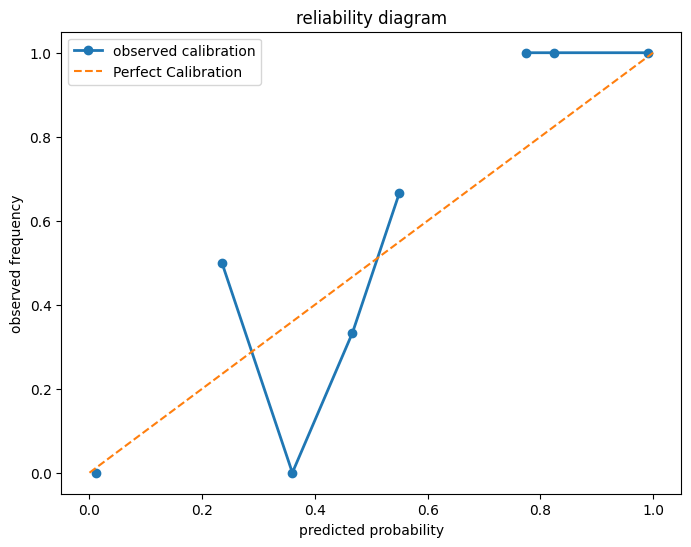

In [7]:
plt.figure(figsize=(8,6))

plt.plot(calibration_table["avg_predicted_probability"], calibration_table["observed_frequency"], marker="o", linewidth=2, 
        label="observed calibration")

plt.plot([0,1],[0,1], linestyle="--", label="Perfect Calibration")

plt.xlabel("predicted probability")
plt.ylabel("observed frequency")

plt.title("reliability diagram")

plt.legend()

plt.show()

## Reliability Diagram Analysis

The reliability diagram suggests that prediction market probabilities exhibit reasonable calibration at the extreme probability regions.

Markets assigned very low probabilities were rarely realized, while markets assigned probabilities close to one were realized almost universally. This behavior is consistent with an informationally efficient market.

However, the intermediate probability regions display substantial variability. Several probability bins deviate noticeably from the perfect calibration line.

These deviations should be interpreted with caution, as most intermediate bins contain only a small number of observations. In several cases, calibration estimates are based on one to three markets, making them highly sensitive to individual outcomes.

Consequently, the observed departures from perfect calibration are more likely attributable to limited sample size rather than definitive evidence of systematic market inefficiency.

Overall, the reliability analysis provides preliminary evidence that Polymarket probabilities are broadly informative, although a larger sample of resolved markets would be required to assess calibration rigorously across the full probability spectrum.


In [8]:
# Expected Calibration Error (ECE)

ece = ((calibration_table["n_markets"] / calibration_table["n_markets"].sum()) * np.abs(calibration_table["observed_frequency"] - 
        calibration_table["avg_predicted_probability"])).sum()

print(f"expected calibration error (ECE): {ece:.4f}")

expected calibration error (ECE): 0.0559


In [11]:
calibration_table["calibration_gap"] = (calibration_table["observed_frequency"] -calibration_table["avg_predicted_probability"])

display(calibration_table[["probability_bin",
            "avg_predicted_probability",
            "observed_frequency",
            "calibration_gap",
            "n_markets"]])

,probability_bin,avg_predicted_probability,observed_frequency,calibration_gap,n_markets
0,"(-0.001, 0.1]",0.012104,0.000000,-0.012104,24
1,"(0.1, 0.2]",NaN,NaN,NaN,0
2,"(0.2, 0.3]",0.235000,0.500000,0.265000,2
3,"(0.3, 0.4]",0.360000,0.000000,-0.360000,1
4,"(0.4, 0.5]",0.466667,0.333333,-0.133333,3
5,"(0.5, 0.6]",0.550000,0.666667,0.116667,3
6,"(0.6, 0.7]",NaN,NaN,NaN,0
7,"(0.7, 0.8]",0.775000,1.000000,0.225000,1
8,"(0.8, 0.9]",0.825000,1.000000,0.175000,1
9,"(0.9, 1.0]",0.990750,1.000000,0.009250,8


## Calibration Analysis Insights

### Expected Calibration Error (ECE)

The Expected Calibration Error (ECE) of the prediction market dataset is: ECE = 0.0559


This result indicates that, on average, market-implied probabilities differ from realized frequencies by approximately 5.6 percentage points.

From a forecasting perspective, this suggests that Polymarket exhibits reasonably good calibration across the available sample of resolved markets.

---

### Insight 1 — Strong Calibration at Probability Extremes

The most notable finding is the strong calibration observed at the extreme probability regions. For markets with probabilities close to zero:

| Probability Bin | Calibration Gap |
| --------------- | --------------- |
| 0–10%           | -0.012          |

For markets with probabilities close to one:

| Probability Bin | Calibration Gap |
| --------------- | --------------- |
| 90–100%         | +0.009          |

These calibration gaps are very small, indicating that events considered highly unlikely rarely occurred, while events considered highly likely almost always occurred.

This behavior is consistent with the expectations of an informationally efficient prediction market.

---

### Insight 2 — Higher Calibration Errors in Intermediate Probability Regions

The largest calibration gaps appear in the intermediate probability ranges.

Examples include:

| Probability Bin | Calibration Gap |
| --------------- | --------------- |
| 20–30%          | +0.265          |
| 30–40%          | -0.360          |

At first glance, these values could suggest underconfidence or overconfidence by market participants.

However, these bins contain very few observations:

| Probability Bin | Number of Markets |
| --------------- | ----------------- |
| 20–30%          | 2                 |
| 30–40%          | 1                 |

Given the extremely small sample sizes, these deviations are more likely the result of sampling variability rather than systematic market bias.

Consequently, no definitive conclusions regarding miscalibration can be drawn from these intermediate regions.

---

### Insight 3 — Probability Mass Concentrated at the Extremes

Most resolved markets are concentrated near probabilities of zero or one.

Specifically:

| Probability Range | Number of Markets |
| ----------------- | ----------------- |
| 0–10%             | 24                |
| 90–100%           | 8                 |

Therefore:  $ 32 \text{ of } 43 \text{ markets} $

are located in the extreme probability regions.

This concentration explains:

* The relatively low Brier Score.
* The relatively low Expected Calibration Error.
* The generally favorable reliability diagram.

It also implies that calibration estimates in the middle probability ranges are statistically less reliable due to limited observations.

---

### Overall Assessment

The calibration analysis provides preliminary evidence that Polymarket probabilities are broadly informative and reasonably calibrated.

Key benchmark metrics obtained from this study are:

| Metric                           | Value  |
| -------------------------------- | ------ |
| Brier Score                      | 0.0532 |
| Expected Calibration Error (ECE) | 0.0559 |

These values will serve as the baseline against which the Bayesian fair-value model developed in the next phase will be evaluated.

The central research question moving forward is whether Bayesian methods can improve probability calibration relative to the market itself.
